# câu 3

6351071057 - Lê Hoàng Phúc

1. Thông tin dữ liệu ban đầu:
6351071057 - Lê Hoàng Phúc
Kích thước dữ liệu: (1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Thông tin

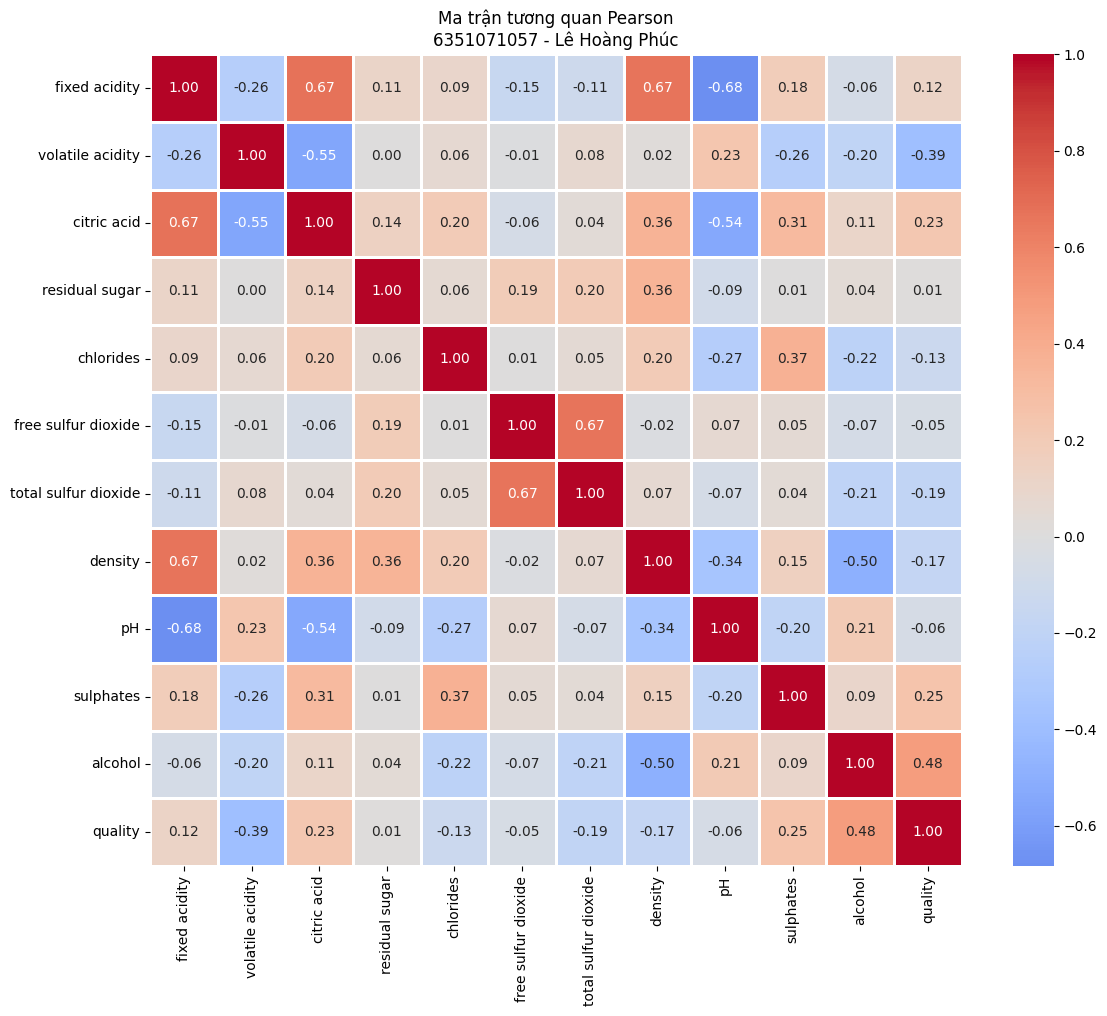


Các cặp cột có tương quan cao (|r| > 0.7):
6351071057 - Lê Hoàng Phúc

Không có cột nào cần loại bỏ.

Kích thước dữ liệu sau khi loại bỏ: (1599, 12)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# In thông tin sinh viên
print("="*60)
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

# Đọc dữ liệu
df = pd.read_csv('winequality-red.csv')

print("\n1. Thông tin dữ liệu ban đầu:")
print("6351071057 - Lê Hoàng Phúc")
print(f"Kích thước dữ liệu: {df.shape}")
print(f"\nThông tin các cột:\n{df.info()}")
print(f"\nThống kê mô tả:\n{df.describe()}")

# YÊU CẦU 3: Khảo sát độ tương đồng bằng Pearson
print("\n" + "="*60)
print("YÊU CẦU 3: KHẢO SÁT ĐỘ TƯƠNG ĐỒNG (PEARSON)")
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

# Tính ma trận tương quan Pearson
correlation_matrix = df.corr(method='pearson')
print("\nMa trận tương quan Pearson:")
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Ma trận tương quan Pearson\n6351071057 - Lê Hoàng Phúc')
plt.tight_layout()
plt.show()

# Tìm các cặp cột có tương quan cao (> 0.7 hoặc < -0.7)
print("\nCác cặp cột có tương quan cao (|r| > 0.7):")
print("6351071057 - Lê Hoàng Phúc")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Column 1': correlation_matrix.columns[i],
                'Column 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })
            print(f"{correlation_matrix.columns[i]} - {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

# Loại bỏ các cột có tương quan cao
# Loại bỏ 'total sulfur dioxide' vì tương quan cao với 'free sulfur dioxide'
columns_to_drop = []
if len(high_corr_pairs) > 0:
    columns_to_drop = ['total sulfur dioxide']  # Có thể điều chỉnh dựa trên phân tích
    print(f"\nCác cột sẽ bị loại bỏ: {columns_to_drop}")
    df_reduced = df.drop(columns=columns_to_drop)
else:
    df_reduced = df.copy()
    print("\nKhông có cột nào cần loại bỏ.")

print(f"\nKích thước dữ liệu sau khi loại bỏ: {df_reduced.shape}")

# Câu 4

In [2]:
# YÊU CẦU 4: Tách dữ liệu thành thuộc tính và nhãn
print("\n" + "="*60)
print("YÊU CẦU 4: TÁCH DỮ LIỆU")
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

X = df_reduced.drop('quality', axis=1)  # Thuộc tính
y = df_reduced['quality']  # Nhãn quyết định

print(f"\nKích thước thuộc tính X: {X.shape}")
print(f"Kích thước nhãn y: {y.shape}")
print(f"\nCác thuộc tính: {list(X.columns)}")
print(f"\nPhân bố nhãn quality:")
print("6351071057 - Lê Hoàng Phúc")
print(y.value_counts().sort_index())


YÊU CẦU 4: TÁCH DỮ LIỆU
6351071057 - Lê Hoàng Phúc

Kích thước thuộc tính X: (1599, 11)
Kích thước nhãn y: (1599,)

Các thuộc tính: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Phân bố nhãn quality:
6351071057 - Lê Hoàng Phúc
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


# Câu 5

In [3]:
# YÊU CẦU 5: Chuyển đổi dữ liệu không phải số về one-hot
print("\n" + "="*60)
print("YÊU CẦU 5: CHUYỂN ĐỔI ONE-HOT ENCODING")
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

# Kiểm tra các cột không phải số
non_numeric_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCác cột không phải số: {non_numeric_cols if non_numeric_cols else 'Không có'}")

if len(non_numeric_cols) > 0:
    X = pd.get_dummies(X, columns=non_numeric_cols, drop_first=True)
    print(f"Kích thước sau one-hot encoding: {X.shape}")
else:
    print("Tất cả các cột đều là số, không cần chuyển đổi.")

print(f"\nCác cột sau xử lý: {list(X.columns)}")



YÊU CẦU 5: CHUYỂN ĐỔI ONE-HOT ENCODING
6351071057 - Lê Hoàng Phúc

Các cột không phải số: Không có
Tất cả các cột đều là số, không cần chuyển đổi.

Các cột sau xử lý: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


# Câu 6

In [4]:
# YÊU CẦU 6: Chia dữ liệu train/test (70/30)
print("\n" + "="*60)
print("YÊU CẦU 6: CHIA DỮ LIỆU TRAIN/TEST")
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nKích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm thử: {X_test.shape}")
print(f"\nPhân bố nhãn trong tập huấn luyện:")
print("6351071057 - Lê Hoàng Phúc")
print(y_train.value_counts().sort_index())
print(f"\nPhân bố nhãn trong tập kiểm thử:")
print(y_test.value_counts().sort_index())



YÊU CẦU 6: CHIA DỮ LIỆU TRAIN/TEST
6351071057 - Lê Hoàng Phúc

Kích thước tập huấn luyện: (1119, 11)
Kích thước tập kiểm thử: (480, 11)

Phân bố nhãn trong tập huấn luyện:
6351071057 - Lê Hoàng Phúc
quality
3      7
4     37
5    477
6    446
7    139
8     13
Name: count, dtype: int64

Phân bố nhãn trong tập kiểm thử:
quality
3      3
4     16
5    204
6    192
7     60
8      5
Name: count, dtype: int64


# Câu 7


YÊU CẦU 7: CÂY QUYẾT ĐỊNH ID3 (ENTROPY)
6351071057 - Lê Hoàng Phúc

Ma trận nhầm lẫn ID3:
6351071057 - Lê Hoàng Phúc
[[  1   0   1   1   0   0]
 [  0   3   8   4   1   0]
 [  0   2 128  68   6   0]
 [  0   2  50 121  15   4]
 [  0   2  11  24  20   3]
 [  0   0   0   0   4   1]]

Độ chính xác ID3: 0.5708

Báo cáo phân loại ID3:
6351071057 - Lê Hoàng Phúc
              precision    recall  f1-score   support

           3       1.00      0.33      0.50         3
           4       0.33      0.19      0.24        16
           5       0.65      0.63      0.64       204
           6       0.56      0.63      0.59       192
           7       0.43      0.33      0.38        60
           8       0.12      0.20      0.15         5

    accuracy                           0.57       480
   macro avg       0.52      0.39      0.42       480
weighted avg       0.57      0.57      0.57       480



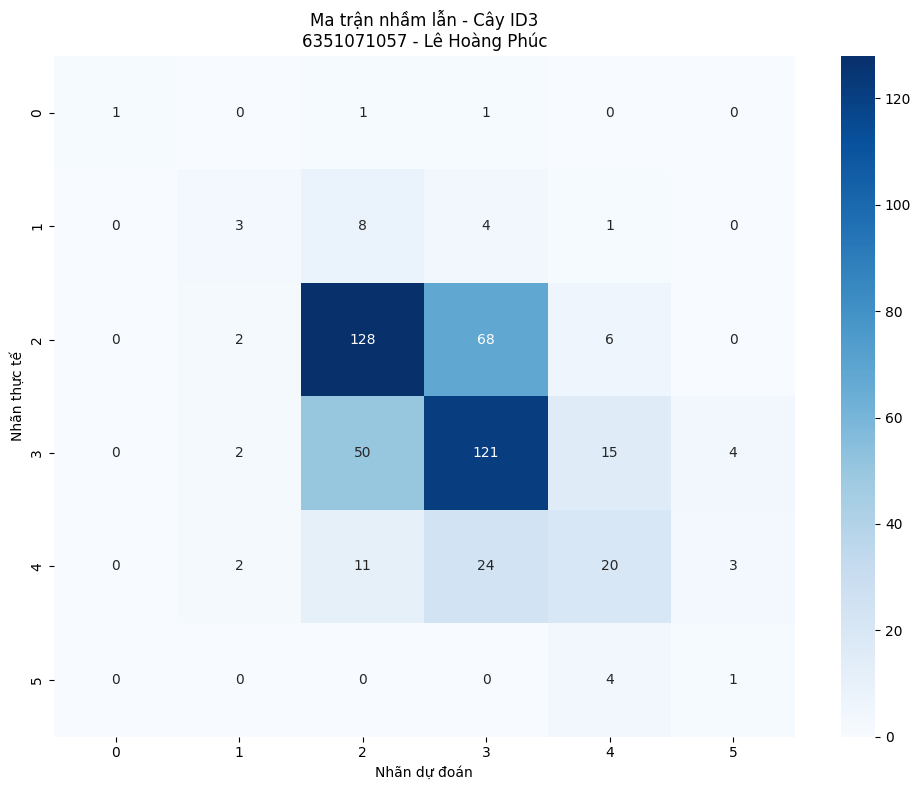

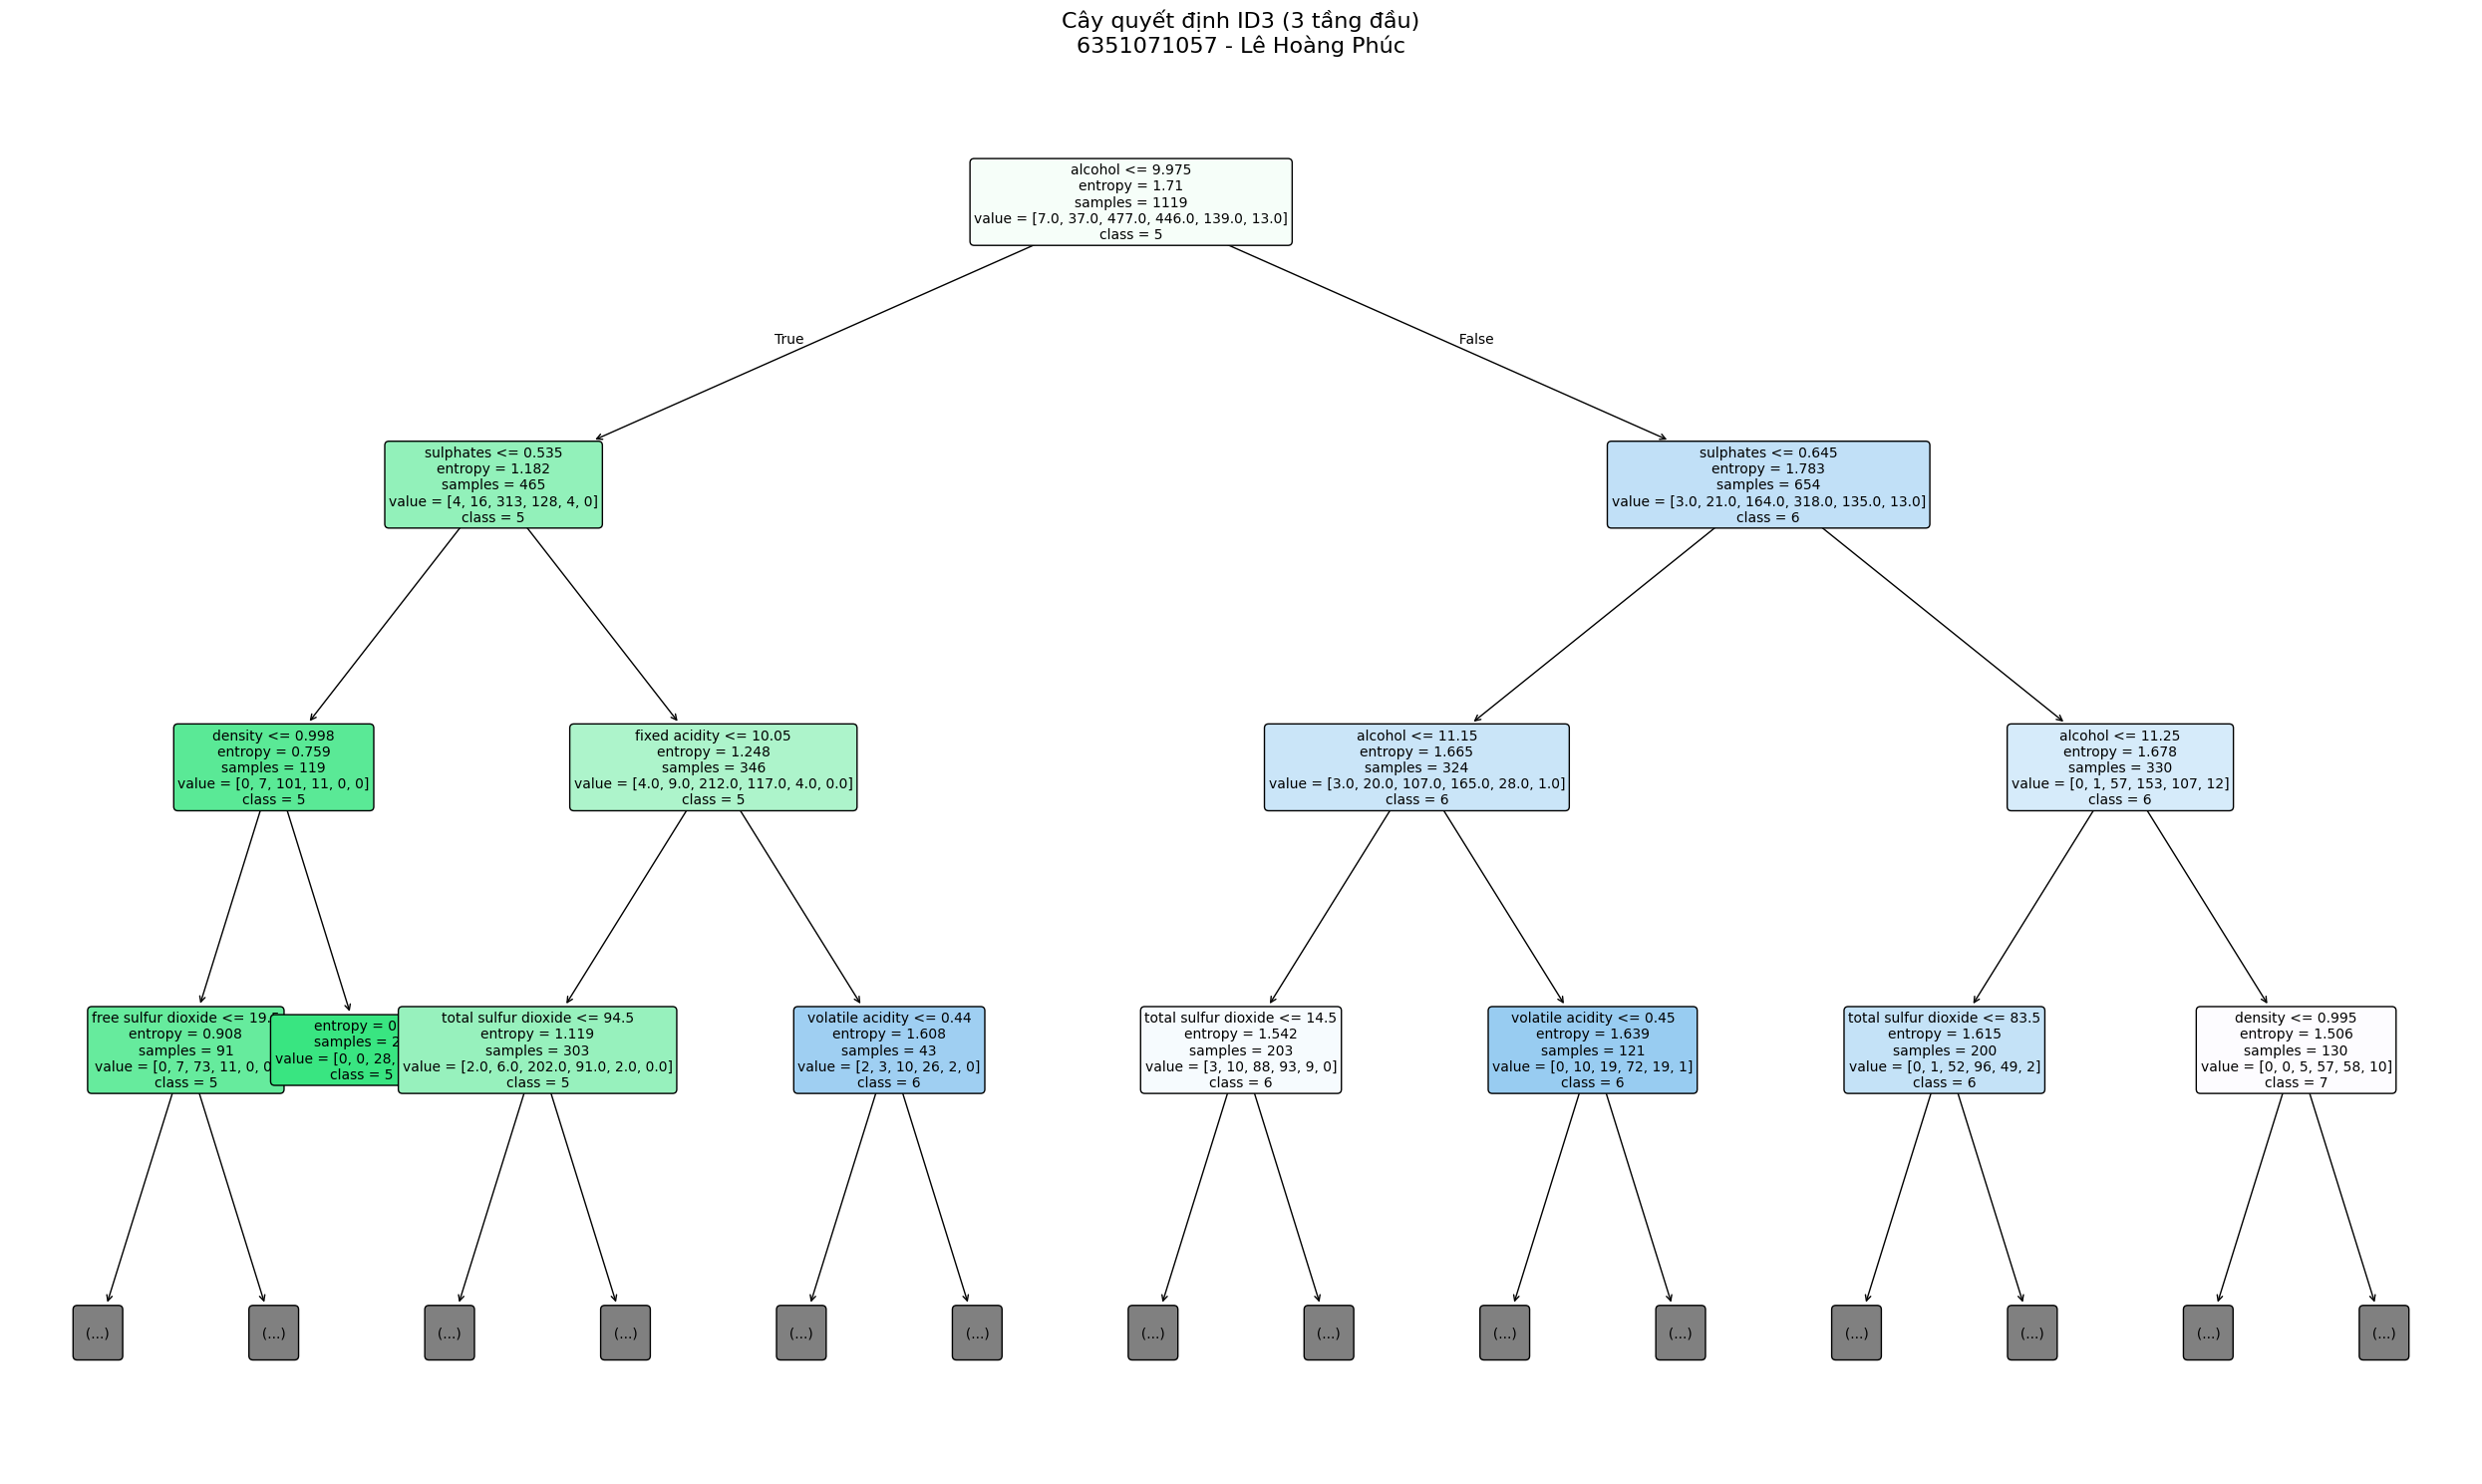


Độ quan trọng của các thuộc tính (ID3):
6351071057 - Lê Hoàng Phúc
                 Feature  Importance
10               alcohol    0.206666
1       volatile acidity    0.138188
9              sulphates    0.125744
3         residual sugar    0.084170
6   total sulfur dioxide    0.078273
5    free sulfur dioxide    0.075768
4              chlorides    0.070517
0          fixed acidity    0.058775
7                density    0.057780
2            citric acid    0.053071


In [5]:
# YÊU CẦU 7: XÂY DỰNG CÂY ID3 (Decision Tree với entropy)
print("\n" + "="*60)
print("YÊU CẦU 7: CÂY QUYẾT ĐỊNH ID3 (ENTROPY)")
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

# ID3 sử dụng entropy làm tiêu chí
id3_model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=10)
id3_model.fit(X_train, y_train)

# Dự đoán
y_pred_id3 = id3_model.predict(X_test)

# Ma trận nhầm lẫn
cm_id3 = confusion_matrix(y_test, y_pred_id3)
print("\nMa trận nhầm lẫn ID3:")
print("6351071057 - Lê Hoàng Phúc")
print(cm_id3)

# Độ chính xác
accuracy_id3 = accuracy_score(y_test, y_pred_id3)
print(f"\nĐộ chính xác ID3: {accuracy_id3:.4f}")

# Classification report
print("\nBáo cáo phân loại ID3:")
print("6351071057 - Lê Hoàng Phúc")
print(classification_report(y_test, y_pred_id3))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_id3, annot=True, fmt='d', cmap='Blues')
plt.title('Ma trận nhầm lẫn - Cây ID3\n6351071057 - Lê Hoàng Phúc')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.show()

# Visualize tree
plt.figure(figsize=(25, 15))
plot_tree(id3_model, feature_names=X.columns, class_names=[str(c) for c in sorted(y.unique())],
          filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title('Cây quyết định ID3 (3 tầng đầu)\n6351071057 - Lê Hoàng Phúc', fontsize=16)
plt.tight_layout()
plt.show()

# Feature importance
feature_importance_id3 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': id3_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nĐộ quan trọng của các thuộc tính (ID3):")
print("6351071057 - Lê Hoàng Phúc")
print(feature_importance_id3.head(10))


# Câu 8


YÊU CẦU 8: CÂY QUYẾT ĐỊNH CART (GINI)
6351071057 - Lê Hoàng Phúc

Ma trận nhầm lẫn CART:
6351071057 - Lê Hoàng Phúc
[[  0   1   2   0   0   0]
 [  0   4   8   4   0   0]
 [  2   7 107  86   2   0]
 [  0   4  36 129  22   1]
 [  0   0   5  28  26   1]
 [  0   0   1   3   1   0]]

Độ chính xác CART: 0.5542

Báo cáo phân loại CART:
6351071057 - Lê Hoàng Phúc
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.25      0.25      0.25        16
           5       0.67      0.52      0.59       204
           6       0.52      0.67      0.58       192
           7       0.51      0.43      0.47        60
           8       0.00      0.00      0.00         5

    accuracy                           0.55       480
   macro avg       0.32      0.31      0.32       480
weighted avg       0.56      0.55      0.55       480



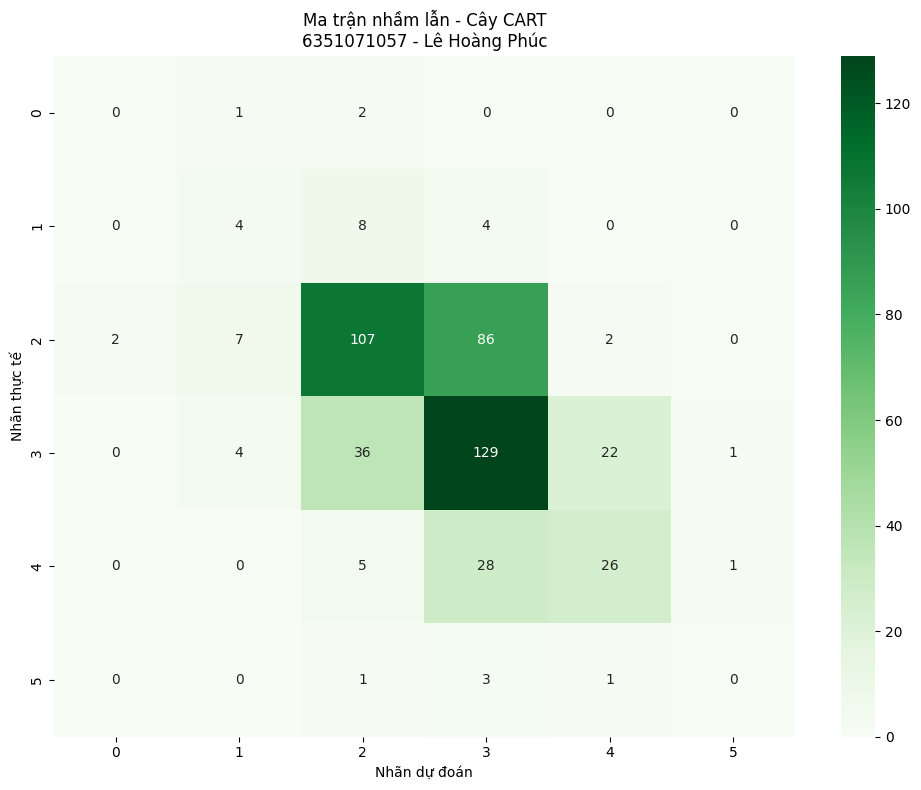

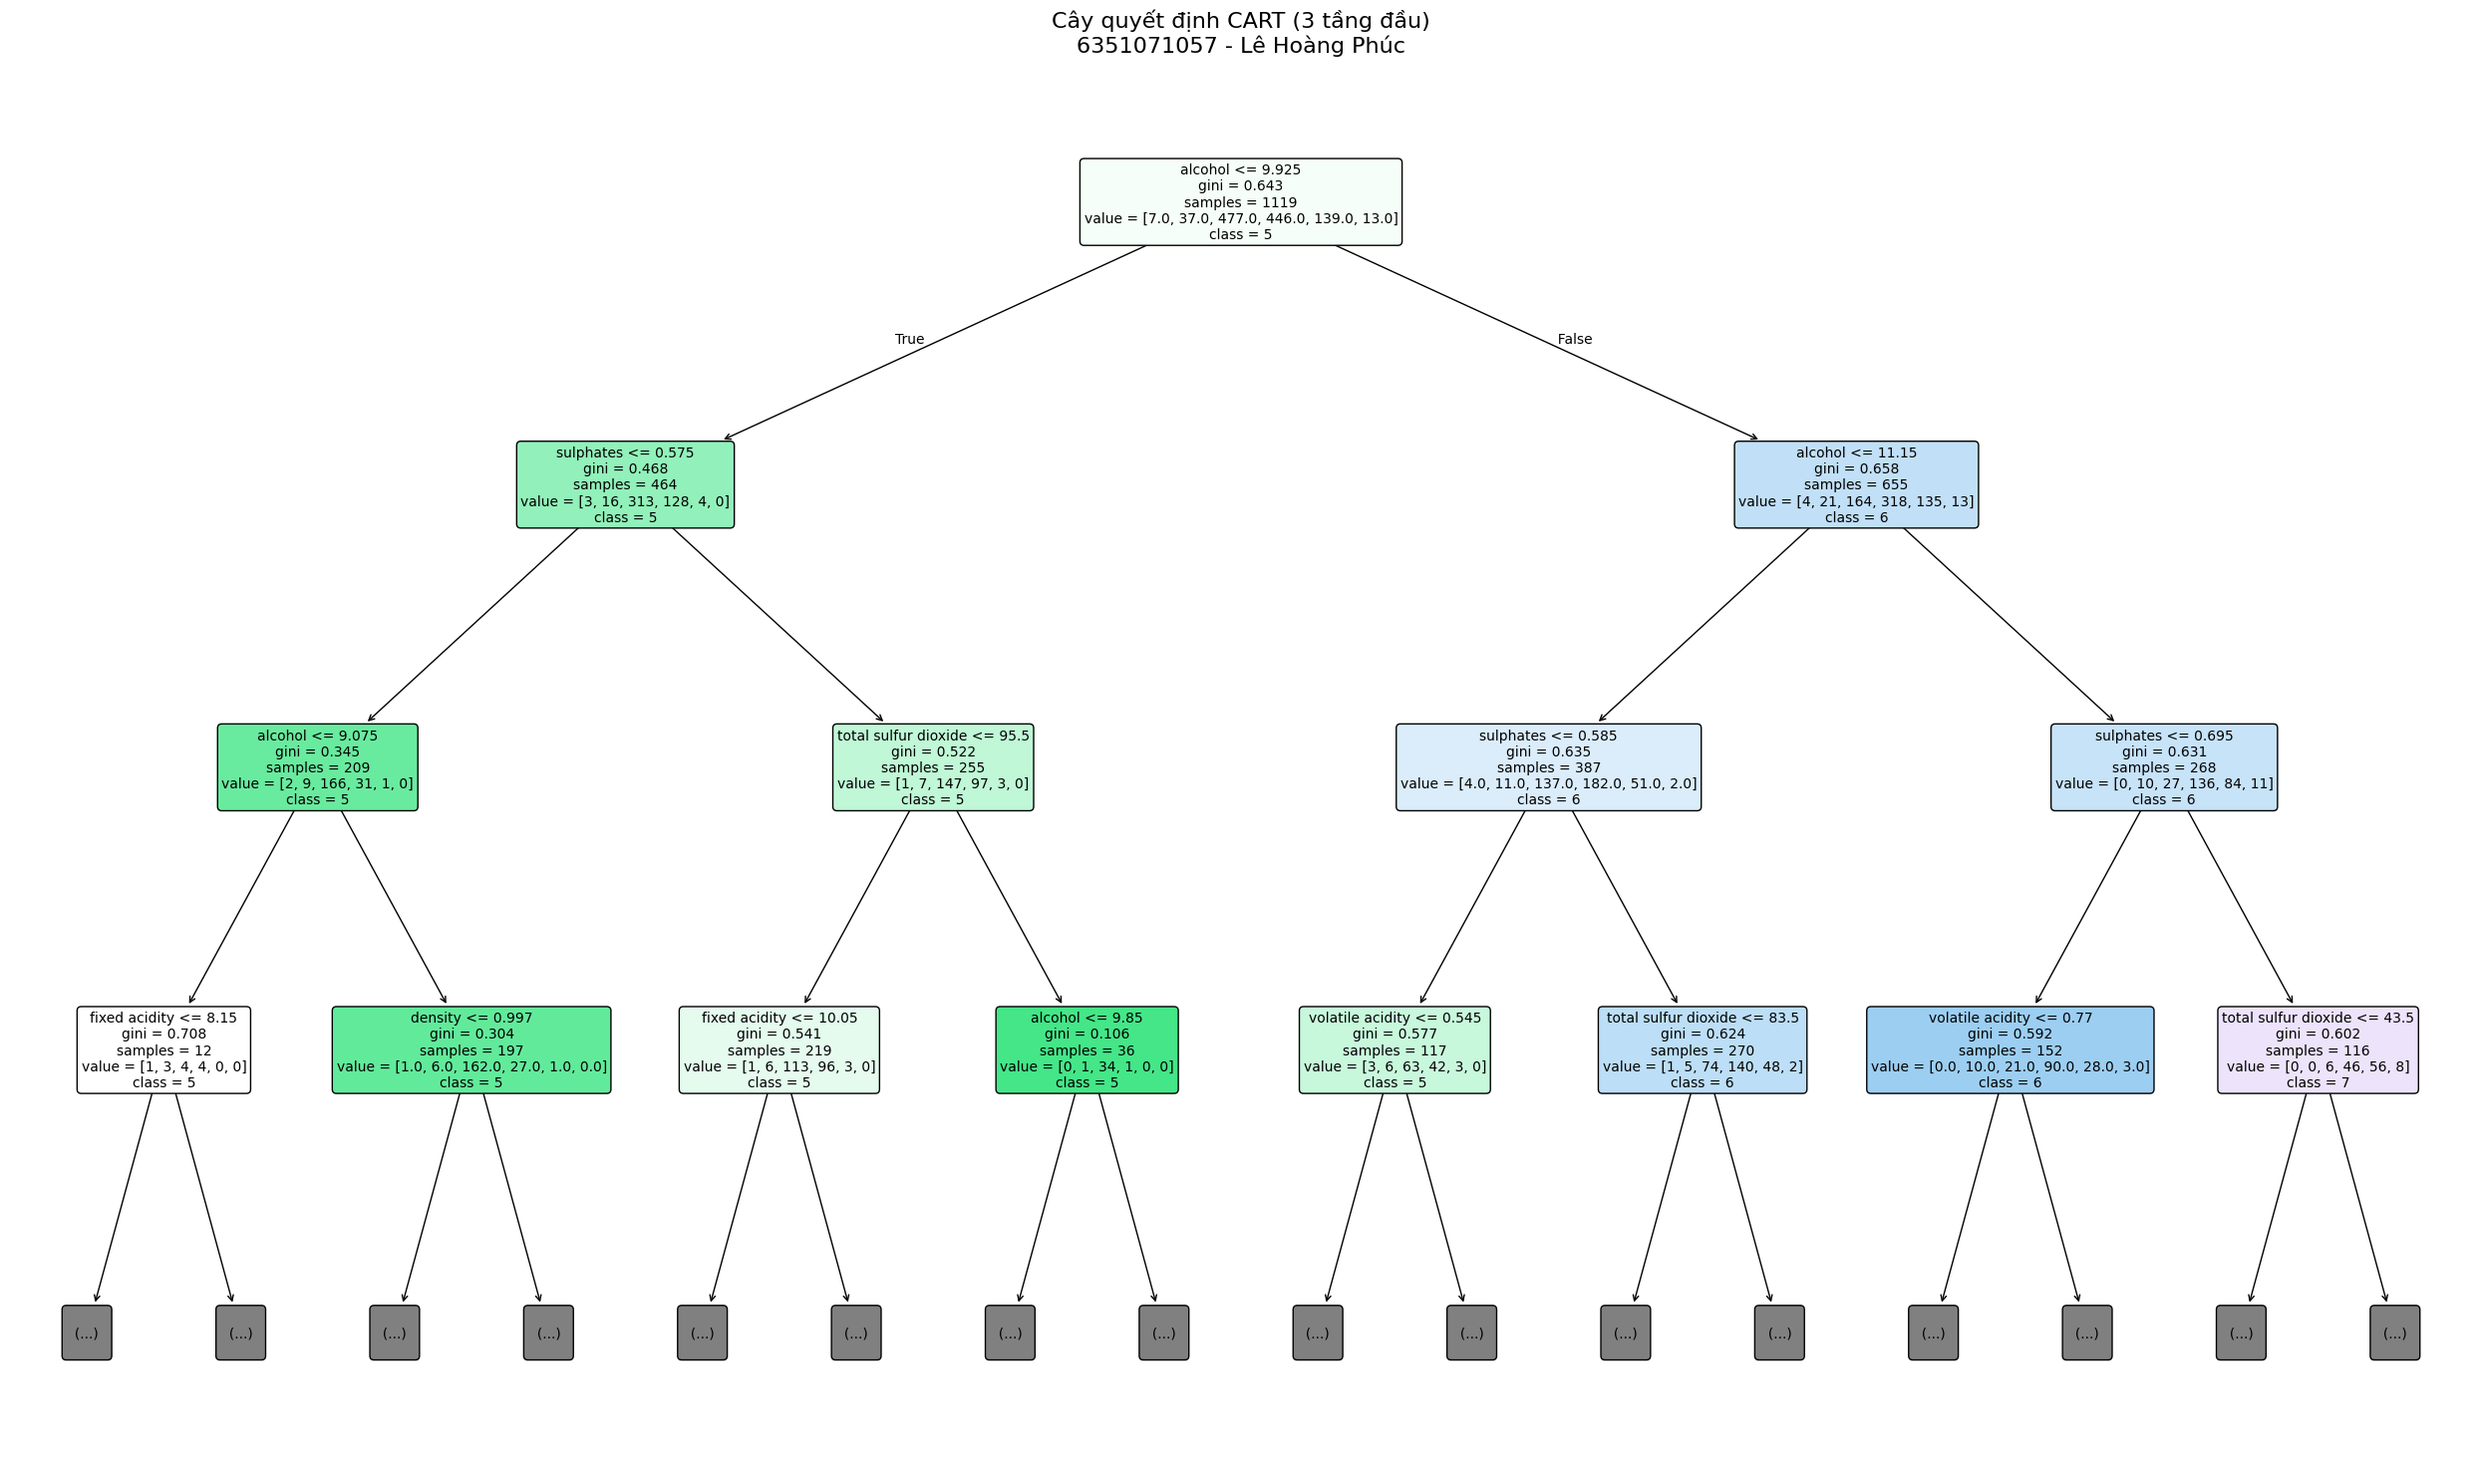


Độ quan trọng của các thuộc tính (CART):
6351071057 - Lê Hoàng Phúc
                 Feature  Importance
10               alcohol    0.217772
9              sulphates    0.117747
6   total sulfur dioxide    0.114191
1       volatile acidity    0.100747
8                     pH    0.090718
0          fixed acidity    0.080064
3         residual sugar    0.072662
4              chlorides    0.069705
7                density    0.067885
5    free sulfur dioxide    0.040922


In [6]:
# YÊU CẦU 8: XÂY DỰNG CÂY CART (Gini)
print("\n" + "="*60)
print("YÊU CẦU 8: CÂY QUYẾT ĐỊNH CART (GINI)")
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

# CART sử dụng gini làm tiêu chí
cart_model = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=10)
cart_model.fit(X_train, y_train)

# Dự đoán
y_pred_cart = cart_model.predict(X_test)

# Ma trận nhầm lẫn
cm_cart = confusion_matrix(y_test, y_pred_cart)
print("\nMa trận nhầm lẫn CART:")
print("6351071057 - Lê Hoàng Phúc")
print(cm_cart)

# Độ chính xác
accuracy_cart = accuracy_score(y_test, y_pred_cart)
print(f"\nĐộ chính xác CART: {accuracy_cart:.4f}")

# Classification report
print("\nBáo cáo phân loại CART:")
print("6351071057 - Lê Hoàng Phúc")
print(classification_report(y_test, y_pred_cart))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cart, annot=True, fmt='d', cmap='Greens')
plt.title('Ma trận nhầm lẫn - Cây CART\n6351071057 - Lê Hoàng Phúc')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.show()

# Visualize tree
plt.figure(figsize=(25, 15))
plot_tree(cart_model, feature_names=X.columns, class_names=[str(c) for c in sorted(y.unique())],
          filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title('Cây quyết định CART (3 tầng đầu)\n6351071057 - Lê Hoàng Phúc', fontsize=16)
plt.tight_layout()
plt.show()

# Feature importance
feature_importance_cart = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cart_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nĐộ quan trọng của các thuộc tính (CART):")
print("6351071057 - Lê Hoàng Phúc")
print(feature_importance_cart.head(10))

# Câu 9


YÊU CẦU 9: NAÏVE BAYES
6351071057 - Lê Hoàng Phúc

Ma trận nhầm lẫn Naïve Bayes:
6351071057 - Lê Hoàng Phúc
[[  1   1   1   0   0   0]
 [  2   1  10   3   0   0]
 [  4   8 131  56   4   1]
 [  0   9  55 102  23   3]
 [  0   1   0  21  34   4]
 [  0   0   0   1   4   0]]

Độ chính xác Naïve Bayes: 0.5604

Báo cáo phân loại Naïve Bayes:
6351071057 - Lê Hoàng Phúc
              precision    recall  f1-score   support

           3       0.14      0.33      0.20         3
           4       0.05      0.06      0.06        16
           5       0.66      0.64      0.65       204
           6       0.56      0.53      0.54       192
           7       0.52      0.57      0.54        60
           8       0.00      0.00      0.00         5

    accuracy                           0.56       480
   macro avg       0.32      0.36      0.33       480
weighted avg       0.57      0.56      0.57       480



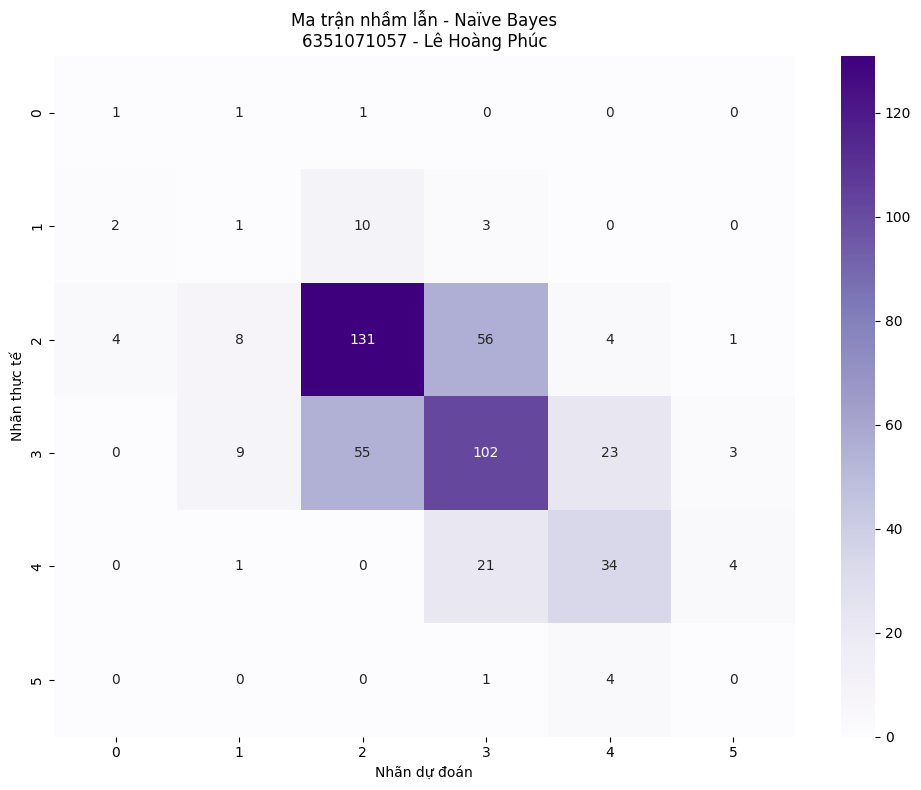

In [7]:
# YÊU CẦU 9: NAÏVE BAYES
print("\n" + "="*60)
print("YÊU CẦU 9: NAÏVE BAYES")
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Dự đoán
y_pred_nb = nb_model.predict(X_test)

# Ma trận nhầm lẫn
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("\nMa trận nhầm lẫn Naïve Bayes:")
print("6351071057 - Lê Hoàng Phúc")
print(cm_nb)

# Độ chính xác
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nĐộ chính xác Naïve Bayes: {accuracy_nb:.4f}")

# Classification report
print("\nBáo cáo phân loại Naïve Bayes:")
print("6351071057 - Lê Hoàng Phúc")
print(classification_report(y_test, y_pred_nb))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples')
plt.title('Ma trận nhầm lẫn - Naïve Bayes\n6351071057 - Lê Hoàng Phúc')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.show()

# Câu 10


YÊU CẦU 10: SO SÁNH CÁC MÔ HÌNH
6351071057 - Lê Hoàng Phúc

Bảng so sánh độ chính xác:
6351071057 - Lê Hoàng Phúc
         Mô hình  Độ chính xác
0  ID3 (Entropy)      0.570833
1    CART (Gini)      0.554167
2    Naïve Bayes      0.560417


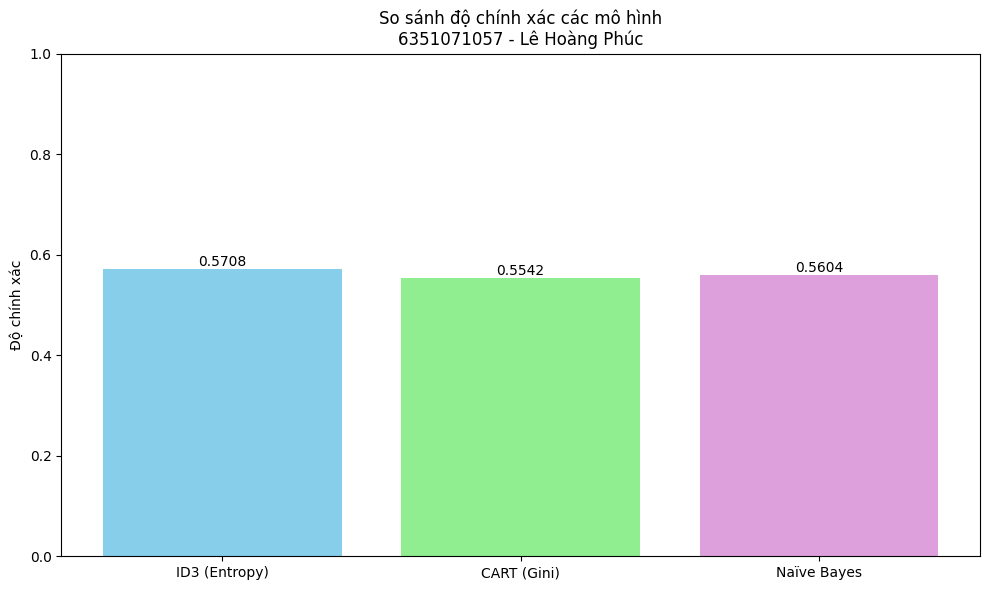


KẾT LUẬN
6351071057 - Lê Hoàng Phúc

Mô hình tốt nhất: ID3 (Entropy)
Độ chính xác: 0.5708

HẾT - 6351071057 - Lê Hoàng Phúc


In [8]:
# YÊU CẦU 10: SO SÁNH CÁC MÔ HÌNH
print("\n" + "="*60)
print("YÊU CẦU 10: SO SÁNH CÁC MÔ HÌNH")
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

# Bảng so sánh
comparison_df = pd.DataFrame({
    'Mô hình': ['ID3 (Entropy)', 'CART (Gini)', 'Naïve Bayes'],
    'Độ chính xác': [accuracy_id3, accuracy_cart, accuracy_nb]
})

print("\nBảng so sánh độ chính xác:")
print("6351071057 - Lê Hoàng Phúc")
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Mô hình'], comparison_df['Độ chính xác'],
               color=['skyblue', 'lightgreen', 'plum'])
plt.ylabel('Độ chính xác')
plt.title('So sánh độ chính xác các mô hình\n6351071057 - Lê Hoàng Phúc')
plt.ylim(0, 1)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Kết luận
print("\n" + "="*60)
print("KẾT LUẬN")
print("6351071057 - Lê Hoàng Phúc")
print("="*60)

best_model = comparison_df.loc[comparison_df['Độ chính xác'].idxmax(), 'Mô hình']
best_accuracy = comparison_df['Độ chính xác'].max()

print(f"\nMô hình tốt nhất: {best_model}")
print(f"Độ chính xác: {best_accuracy:.4f}")

print("\n" + "="*60)
print("HẾT - 6351071057 - Lê Hoàng Phúc")
print("="*60)